<a href="https://colab.research.google.com/github/judahm12/Penn-Aerial-Robotics-Submission/blob/main/Penn_Aerial_Robotics_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

In [ ]:
example_image = cv2.imread("/content/sample_data/PennAir 2024 App Static (1).png")

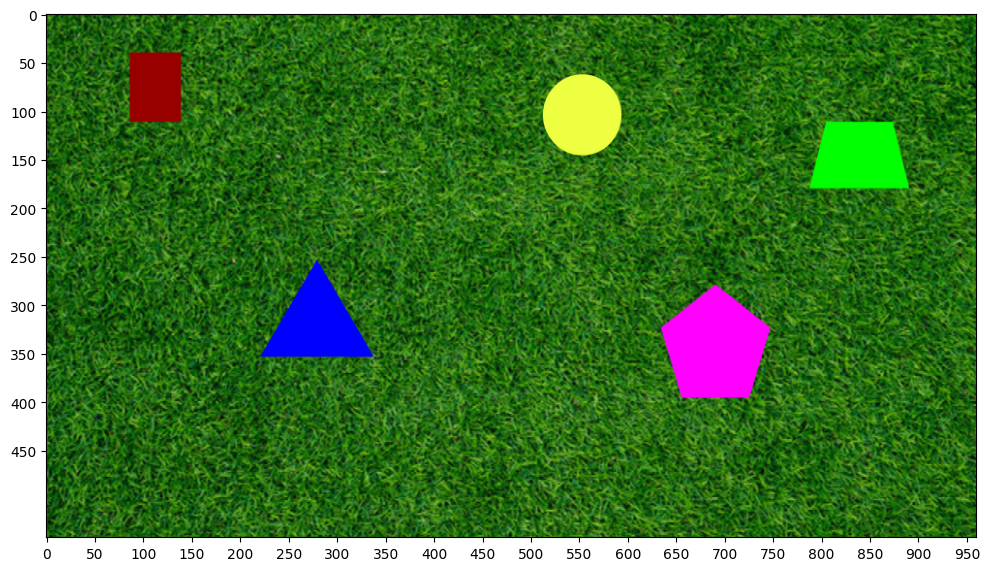

In [ ]:
plt.figure(figsize=(12, 8))
plt.xticks(range(0, 1000, 50))
plt.yticks(range(0, 500, 50))
plt.imshow(cv2.cvtColor(example_image, cv2.COLOR_BGR2RGB))
plt.show()


#making grass mask based on static image bc background doesn't change for step 2
grass_hsv_data = np.empty((0,3))
example_frame_hsv = cv2.cvtColor(example_image, cv2.COLOR_BGR2HSV)
#iterating through known patches of grass to find average hsv values of background
for y in range(150,500):
  for x in range(0,150):
    hsv_pixel = example_frame_hsv[y][x]
    grass_hsv_data = np.vstack((grass_hsv_data, hsv_pixel)) # stacking rows of hsv pixel data
for y in range(0,200):
  for x in range(150,450):
    hsv_pixel = example_frame_hsv[y][x]
    grass_hsv_data = np.vstack((grass_hsv_data, hsv_pixel)) # stacking rows of hsv pixel data

for y in range(0,225):
  for x in range(625,750):
    hsv_pixel = example_frame_hsv[y][x]
    grass_hsv_data = np.vstack((grass_hsv_data, hsv_pixel))

grass_hsv_mean = grass_hsv_data.mean(axis=0)
grass_hsv_sd = grass_hsv_data.std(axis=0) # hue seems to be low variance, saturation and brightness are high var
grass_hsv_min = grass_hsv_data.min(axis=0)
grass_hsv_max = grass_hsv_data.max(axis=0)
# print(f"Grass HSV Mean: {grass_hsv_mean}")
# print(f"Grass HSV SD: {grass_hsv_sd}")
# print(f"Grass HSV Min: {grass_hsv_min}")
# print(f"Grass HSV Max: {grass_hsv_max}")


#creating binary mask to differentiate grass from everything else
grass_hue_mean, grass_hue_sd = grass_hsv_mean[0], grass_hsv_sd[0]
grass_hue_min, grass_hue_max = grass_hsv_min[0], grass_hsv_max[0]



In [ ]:
def detect_shapes_grass(frame):
  hsv_image = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

  h, s, v = cv2.split(hsv_image) # separating three channels from hsv image to make mask
  # grass_mask = cv2.inRange(h, grass_hue_mean - 1.5*grass_hue_sd, grass_hue_mean + 1.5*grass_hue_sd)
  grass_mask = cv2.inRange(h, grass_hue_min, grass_hue_max)

  shape_mask = cv2.bitwise_not(grass_mask)
  # cv2_imshow(shape_mask)

  #creating second bitmask based on local saturation variance - grass has high saturation and brightness variance
  blurred_saturation = cv2.GaussianBlur(s, (17,17), 0)
  texture_s = cv2.absdiff(blurred_saturation, s) # high pass filter
  # initially used mean and stdev, switched to median and mad (0 * std is bc I was tuning the threshold w sd)
  _, low_texture_mask = cv2.threshold(texture_s, texture_s.mean() + 0*texture_s.std(), 255, cv2.THRESH_BINARY_INV) #inv - 0 if above threshold, 255 if below

  opening_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
  cleaned_s_mask = cv2.morphologyEx(low_texture_mask, cv2.MORPH_OPEN, opening_kernel) # noise that's left now is noise that happens to be bigger than 7x7



  rescued_pixels = cv2.bitwise_and(grass_mask, cleaned_s_mask) #pixels that are called grass but have low local saturation variance

  final_mask = cv2.bitwise_or(rescued_pixels, shape_mask) #either rescued or part of original not grass (shape) mask

  #trying to get rid of additional noise with morphology will melt edges of shapes - filter by area of region now
  # contours is a list of blobs, where each element is an array of x,y points demarcating the boundary of blob
  # CHAIN_Approx_simple compresses straight line segments to their endpoints, saving memory

  contours, hierarchy = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  for c in contours:
    area = cv2.contourArea(c)
    if area < 400: #smallest area shape
      continue

    epsilon = 0.007 * cv2.arcLength(c, True) # setting tolerance to be 0.7% of perimeter length
    filtered_c = cv2.approxPolyDP(c, epsilon, True) #choosing to keep points that have d>eps from other points (squiggles next to true edges get deleted, corners are kept)

    cv2.drawContours(output, [filtered_c], -1, (0,0,0), 3)
    # centroiding
    M = cv2.moments(filtered_c) # opencv can calculate moments from contour, rather than entire mask
    if M['m00'] == 0: #to protect against divide by zero error
      continue

    cx = int(M['m10'] / M['m00']) #weighted avg of x coords of shape
    cy = int(M['m01'] / M['m00']) #'' y coords
    cv2.circle(output, (cx, cy), 5, (0, 0, 0), -1) # draw circle at centroid
    cv2.putText(output, f"({cx}, {cy})", (cx + 10, cy - 10),
cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1) #displays coords of centroid on video

  # return output, contour_a_list
  return output


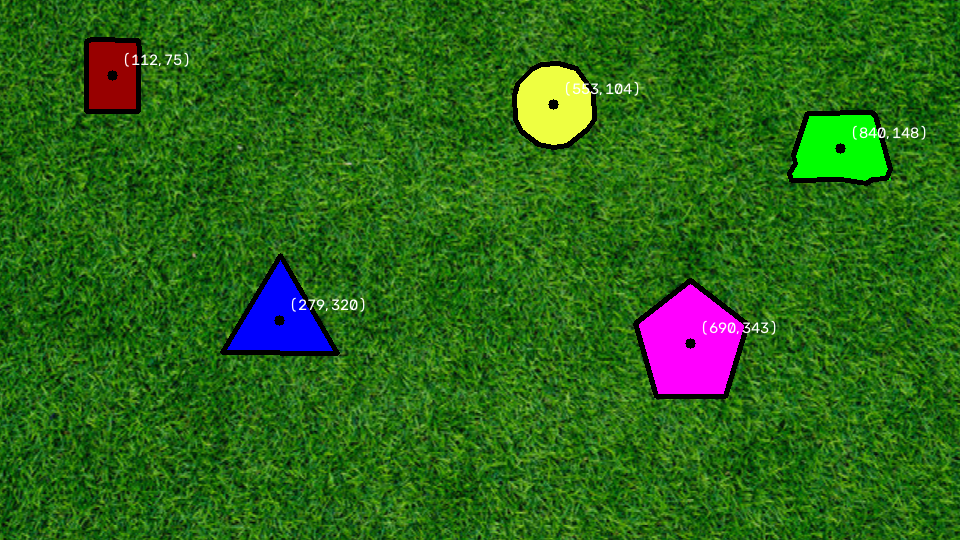

In [ ]:
example_output = detect_shapes_grass(example_image)
cv2_imshow(example_output)

In [ ]:
vid_2 = cv2.VideoCapture("/content/sample_data/PennAir 2024 App Dynamic.mp4")

fps = vid_2.get(cv2.CAP_PROP_FPS)
width = int(vid_2.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vid_2.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v') #gives 4-digit code to identify the codec used to compress video
out = cv2.VideoWriter('output_part2.mp4', fourcc, fps, (width, height))

frame_idx = 0

while True:
  ret, frame = vid_2.read() #gives you next frame, ret is a bool indicating whether a frame was read - false once you run out of frames
  if not ret:
    break

  output = detect_shapes_grass(frame)
  out.write(output)
  frame_idx += 1


vid_2.release() #basically closes these files, allows release of video file handle (OS level pointer to open file)
out.release()

In [ ]:
vid_3 = cv2.VideoCapture("/content/sample_data/PennAir 2024 App Dynamic Hard.mp4")


fps = vid_3.get(cv2.CAP_PROP_FPS)
width = int(vid_3.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vid_3.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(vid_3.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v') #gives 4-digit code to identify the codec used to compress video
out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))
start_frame = 0

frame_idx = 0

open_r = 2   # extinguishes isolated white dots
close_r = 10 # fills interior holes of shapes and the shapes' boundaries
min_area_frac = 5e-4

def local_sd(gray, window_size):
  '''calculating sliding window standard deviation to differentiate noisy background from smooth color gradient of shapes'''
  #using E[x^2] - E[x]^2 identity
  # use greyscale because we're looking more at spatial variance than hue variance for smoothness

  g = gray.astype(np.float32)
  mu  = cv2.boxFilter(g, cv2.CV_32F, (window_size, window_size))
  mu2 = cv2.boxFilter(g*g, cv2.CV_32F, (window_size, window_size))
  sigma = cv2.sqrt(np.maximum(mu2 - mu*mu, 0))
  return sigma

def sd_blur(local_sd, window_size):
  return cv2.boxFilter(local_sd, cv2.CV_32F, (window_size, window_size)) #32 bit floats so mu*mu doesn't wrap around

restoration_radius = 10


def smooth_region_mask(gray):
  g = gray.astype(np.float32)
  # basically adding a high pass filter here to improve contour for trapezoid
  g = g - cv2.GaussianBlur(g, (0, 0), 3.0) #

  sd = local_sd(g, 3) #calculating intensity sd for frame
  med_local_sd = float(np.median(sd))
  mad_local_sd = float(np.median(np.abs(sd - med_local_sd)))
  cap = med_local_sd + 1 * 1.4826 * mad_local_sd # capping local sd values > 1 sigma above median
  sd = np.minimum(sd, cap) #  so that spikes in sd from shapes' color gradients are discounted
  # get blurred out
  sd_blurred = sd_blur(sd, 31)

  # use median instead of stdev because median is more resistant to outlier(shapes)
  # we want the threshold to be based mostly on value of background, ignoring as much shape data as possible
  median = float(np.median(sd_blurred)) # calculating median texture value
  median_abs_dev = float(np.median(np.abs(sd_blurred - median))) #roughly half of data is
  #within one mad of median by construction
  sigma = 1.4826 * median_abs_dev # this is roughly the scale factor to go from mad -> sigma for normal background

  threshold = median - 4 * sigma
  mask = (sd_blurred < threshold).astype(np.uint8) * 255

  return mask, threshold, median, sigma

def clean_mask(mask):
  # choose small open kernel bc the pixels that survived the filtering can't be too big, as the 31x31 kernel
  # caught most of the background noise
  # if we make it larger than it could get rid of true shape edges that are on the smaller side
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*open_r + 1, 2*open_r + 1)))
  # close mask can be larger bc we want to fill holes
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*close_r + 1, 2*close_r + 1)))

  # we are going to filter the mask blobs by size before dilating the mask blobs so we don't
  min_area = min_area_frac * mask.size #mask.size is tot. # of pixels in mask
  n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8) #finds every island of contiguous white pixels
  # n-1 is number of actual blobs, first is background
  #lab holds ID of each blob
  # stats contains, among other things, area of each blob
  # pass 8 into above function to count diagonally touching white pixels as a connection (for circle)

  mask = np.zeros_like(mask)
  for i in range(1, n):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
      mask[labels == i] = 255 #if that blob's area is above threshold, make all of the pixels in that blob white

  dilated = cv2.dilate(mask, cv2.getStructuringElement(
      cv2.MORPH_ELLIPSE, (restoration_radius * 2 + 1, restoration_radius * 2 + 1)))
  return dilated


def detect(mask, frame_area):
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  output = []

  for c in contours:
    area = cv2.contourArea(c)
    if min_area_frac * frame_area > area: #comparing contour area to min_area threshold
      continue

    m = cv2.moments(c)
    if m["m00"] == 0:
        continue
    cx, cy = m["m10"] / m["m00"], m["m01"] / m["m00"] #centroid
    output.append((c, (cx, cy), area))

  return output


K = np.array([[2564.3186869, 0, 0], [0, 2569.70273111, 0], [0, 0, 1]])

fx, fy = K[0, 0], K[1, 1]
f = np.sqrt(fx * fy) #use geometric mean because I'm deriving radius from area, which depends on product of
#fx and fy

# assume center of camera to be at center of frame
c_x, c_y = width / 2.0, height / 2.0

circle_radius_in = 10
in_to_m = 0.0254

def pixel_to_camera(cx_px, cy_px, Z):
  X = (cx_px - c_x) * Z/f
  Y = (cy_px - c_y) * Z/f
  return X, Y, Z


frame_idx = 0


while True:
  ret, frame = vid_3.read()
  if not ret:
    break
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

  mask, threshold, median, sigma = smooth_region_mask(gray)
  mask = clean_mask(mask)
  dets = detect(mask, gray.size)

  # find the roundest contour (the circle, the only shape whose real size we know)
  best_score = 0
  circle_area = None

  for c, center, area in dets:
      perimeter = cv2.arcLength(c, True)

      if perimeter == 0:
          continue
      score = 4 * np.pi * area / (perimeter * perimeter)   # 1.0 = perfect circle

      if score > best_score:
          best_score = score
          circle_area = area

  # depth based on the circle's apparent size
  Z = None
  if circle_area is not None:
      r_px = np.sqrt(circle_area / np.pi)
      Z = f * circle_radius_in / r_px * in_to_m

  for c, (u, v), area in dets:
      cv2.drawContours(frame, [c], -1, (0, 255, 0), 3)
      cv2.circle(frame, (int(u), int(v)), 6, (0, 0, 255), -1)

      if Z is not None:
        # all shapes are on same plane as the circle, so they share its Z value
        X, Y, _ = pixel_to_camera(u, v, Z)
        label = f"({X:+.2f}, {Y:+.2f}, {Z:.2f})m"
      else:
        label = f"({int(u)}, {int(v)})px"

      cv2.putText(frame, label,
                  (int(u) + 12, int(v) - 12),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)

  out.write(frame)


  frame_idx += 1

vid_3.release()
out.release()
print("done:", frame_idx, "frames")


r_px=100.1  Z=6.51 m
r_px=100.1  Z=6.52 m
r_px=99.9  Z=6.53 m
done: 1841 frames
